# PADChest224 - Exploratory Data Analysis (EDA)

### 1. IMPORT LIBRARIES:

In [21]:
import os
import ast
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from collections import Counter

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

### 2. DATASET PATHS:

In [37]:
CSV_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive\PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv"

IMAGES_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive/images-224/images-224"

print("CSV Path :", CSV_PATH)
print("Images Path :", IMAGES_PATH)




CSV Path : C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive\PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv
Images Path : C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\archive/images-224/images-224


### 3. LOAD DATASET:

In [38]:
df = pd.read_csv(CSV_PATH)

print("Dataset Shape :", df.shape)

display(df.head())


Dataset Shape : (160861, 36)


,Index,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,...,ExposureTime,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,...,10.0,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[]
1,1,135803415504923515076821959678074435083_fzis7d...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,LATERAL,L,...,25.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
2,2,135803415504923515076821959678074435083_fzis7b...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,POSTEROANTERIOR,PA,...,10.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
3,3,113855343774216031107737439268243531979_3k951l...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,POSTEROANTERIOR,PA,...,8.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
4,4,113855343774216031107737439268243531979_3k951n...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,LATERAL,L,...,20.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']


### 4. FIRST LOOK AT THE DATASET:

In [39]:
TARGET_DISEASES = [
    'normal',
    'copd signs',
    'cardiomegaly',
    'pleural effusion',
    'interstitial pattern',
    'alveolar pattern',
    'nodule',
    'atelectasis',
    'hilar enlargement',
    'pulmonary fibrosis',
    'tuberculosis sequelae',
    'rib fracture',
    'pneumothorax',
    'mediastinal mass'
]

print("Number of selected diseases :", len(TARGET_DISEASES))

Number of selected diseases : 14


### 5. CHECK MISSING VALUES:

In [40]:
filtered_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    try:

        labels = ast.literal_eval(row['Labels'])

        labels = [
            label.lower().strip()
            for label in labels
        ]

        matched_labels = [
            label for label in labels
            if label in TARGET_DISEASES
        ]

        if len(matched_labels) > 0:

            row['FilteredLabels'] = matched_labels

            filtered_rows.append(row)

    except:
        continue

filtered_df = pd.DataFrame(filtered_rows)

print("\nFiltered Dataset Shape :", filtered_df.shape)

100%|██████████| 160861/160861 [01:06<00:00, 2421.30it/s]



Filtered Dataset Shape : (107116, 37)


In [41]:
counter = Counter()

for labels in filtered_df['FilteredLabels']:

    counter.update(labels)

disease_counts = pd.DataFrame(
    counter.items(),
    columns=['Disease', 'Count']
)

disease_counts = disease_counts.sort_values(
    by='Count',
    ascending=False
)

display(disease_counts)

,Disease,Count
0,normal,50616
5,copd signs,23280
7,cardiomegaly,15028
4,pleural effusion,10026
3,interstitial pattern,7831
2,alveolar pattern,5739
10,nodule,3781
6,atelectasis,2905
11,hilar enlargement,1541
1,pulmonary fibrosis,1228


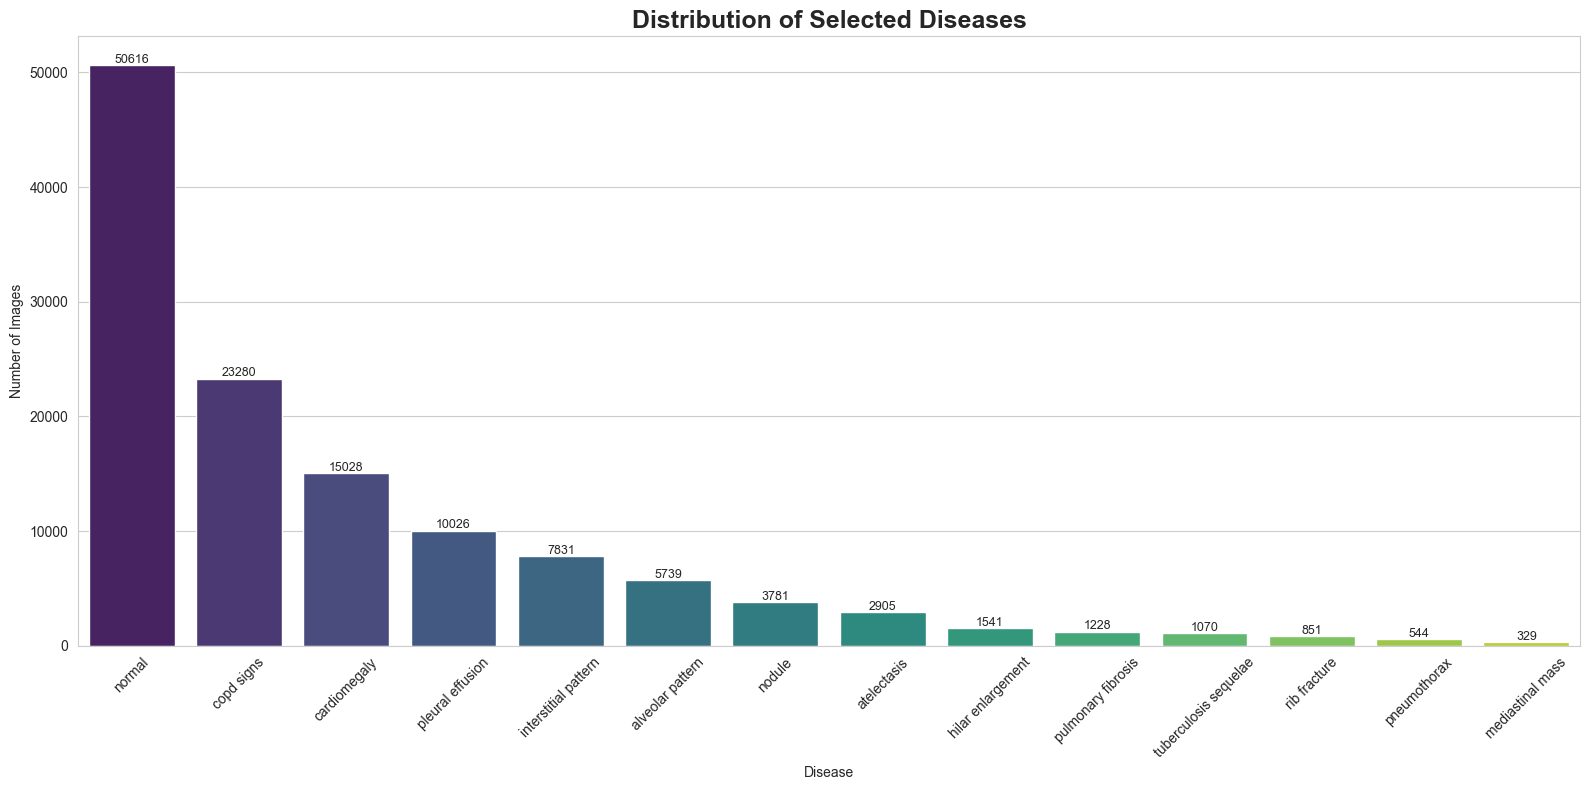

In [27]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=disease_counts,
    x='Disease',
    y='Count',
    palette='viridis'
)

for index, value in enumerate(disease_counts['Count']):

    plt.text(
        index,
        value + 200,
        str(value),
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=45)

plt.title(
    "Distribution of Selected Diseases",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.tight_layout()

plt.show()

In [43]:
single_label_df = filtered_df[
    filtered_df['FilteredLabels'].apply(
        lambda x: len(x) == 1
    )
]

print("\nSingle Label Dataset Shape :", single_label_df.shape)



Single Label Dataset Shape : (92737, 37)


In [44]:
single_counter = Counter()

for labels in single_label_df['FilteredLabels']:

    single_counter.update(labels)

single_counts = pd.DataFrame(
    single_counter.items(),
    columns=['Disease', 'Count']
)

single_counts = single_counts.sort_values(
    by='Count',
    ascending=False
)

display(single_counts)

,Disease,Count
0,normal,50501
3,copd signs,17916
6,cardiomegaly,9271
2,pleural effusion,4511
5,interstitial pattern,2589
11,nodule,2169
9,alveolar pattern,1864
4,atelectasis,1014
10,hilar enlargement,725
7,tuberculosis sequelae,631


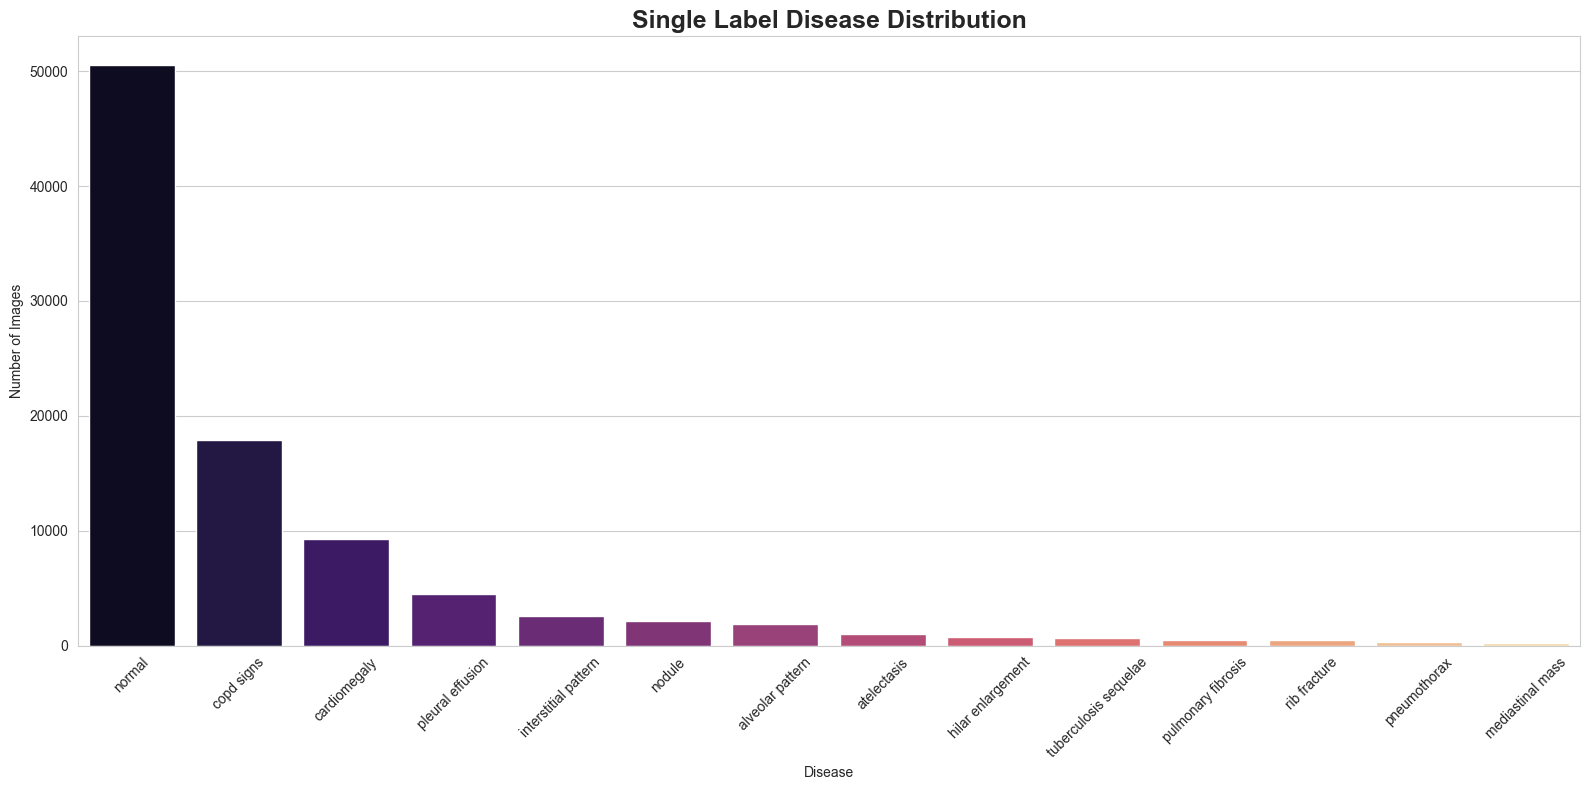

In [45]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=single_counts,
    x='Disease',
    y='Count',
    palette='magma'
)

plt.xticks(rotation=45)

plt.title(
    "Single Label Disease Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.tight_layout()

plt.show()

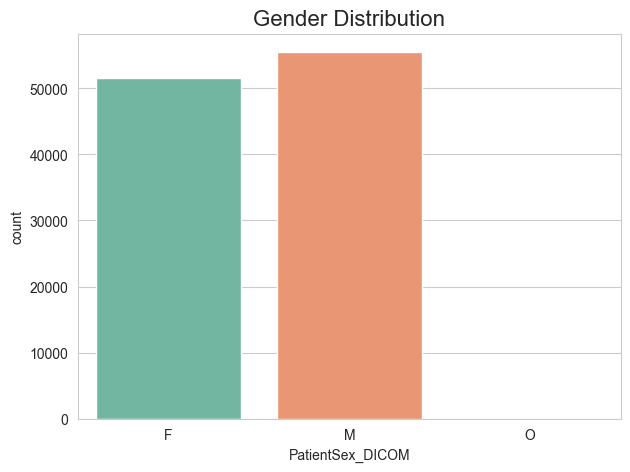

In [31]:
if 'PatientSex_DICOM' in filtered_df.columns:

    plt.figure(figsize=(7,5))

    sns.countplot(
        data=filtered_df,
        x='PatientSex_DICOM',
        palette='Set2'
    )

    plt.title(
        "Gender Distribution",
        fontsize=16
    )

    plt.show()

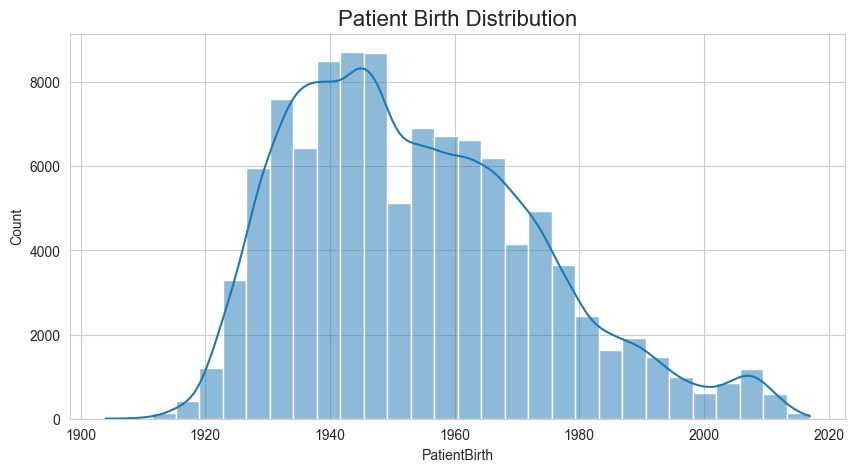

In [32]:
if 'PatientBirth' in filtered_df.columns:

    plt.figure(figsize=(10,5))

    sns.histplot(
        filtered_df['PatientBirth'].dropna(),
        bins=30,
        kde=True
    )

    plt.title(
        "Patient Birth Distribution",
        fontsize=16
    )

    plt.show()

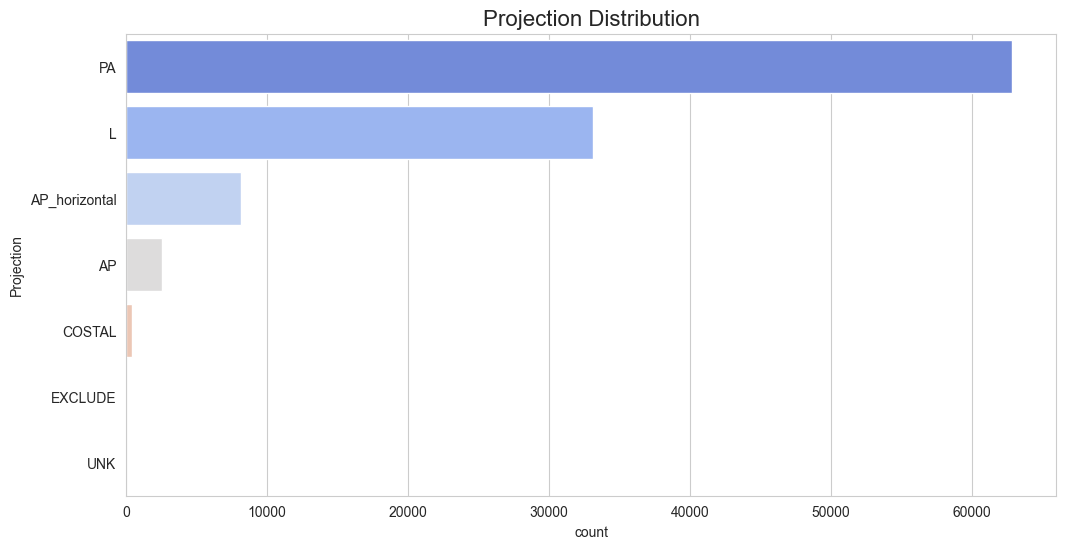

In [33]:
if 'Projection' in filtered_df.columns:

    projection_counts = filtered_df['Projection'].value_counts()

    plt.figure(figsize=(12,6))

    sns.countplot(
        y=filtered_df['Projection'],
        order=projection_counts.index,
        palette='coolwarm'
    )

    plt.title(
        "Projection Distribution",
        fontsize=16
    )

    plt.show()

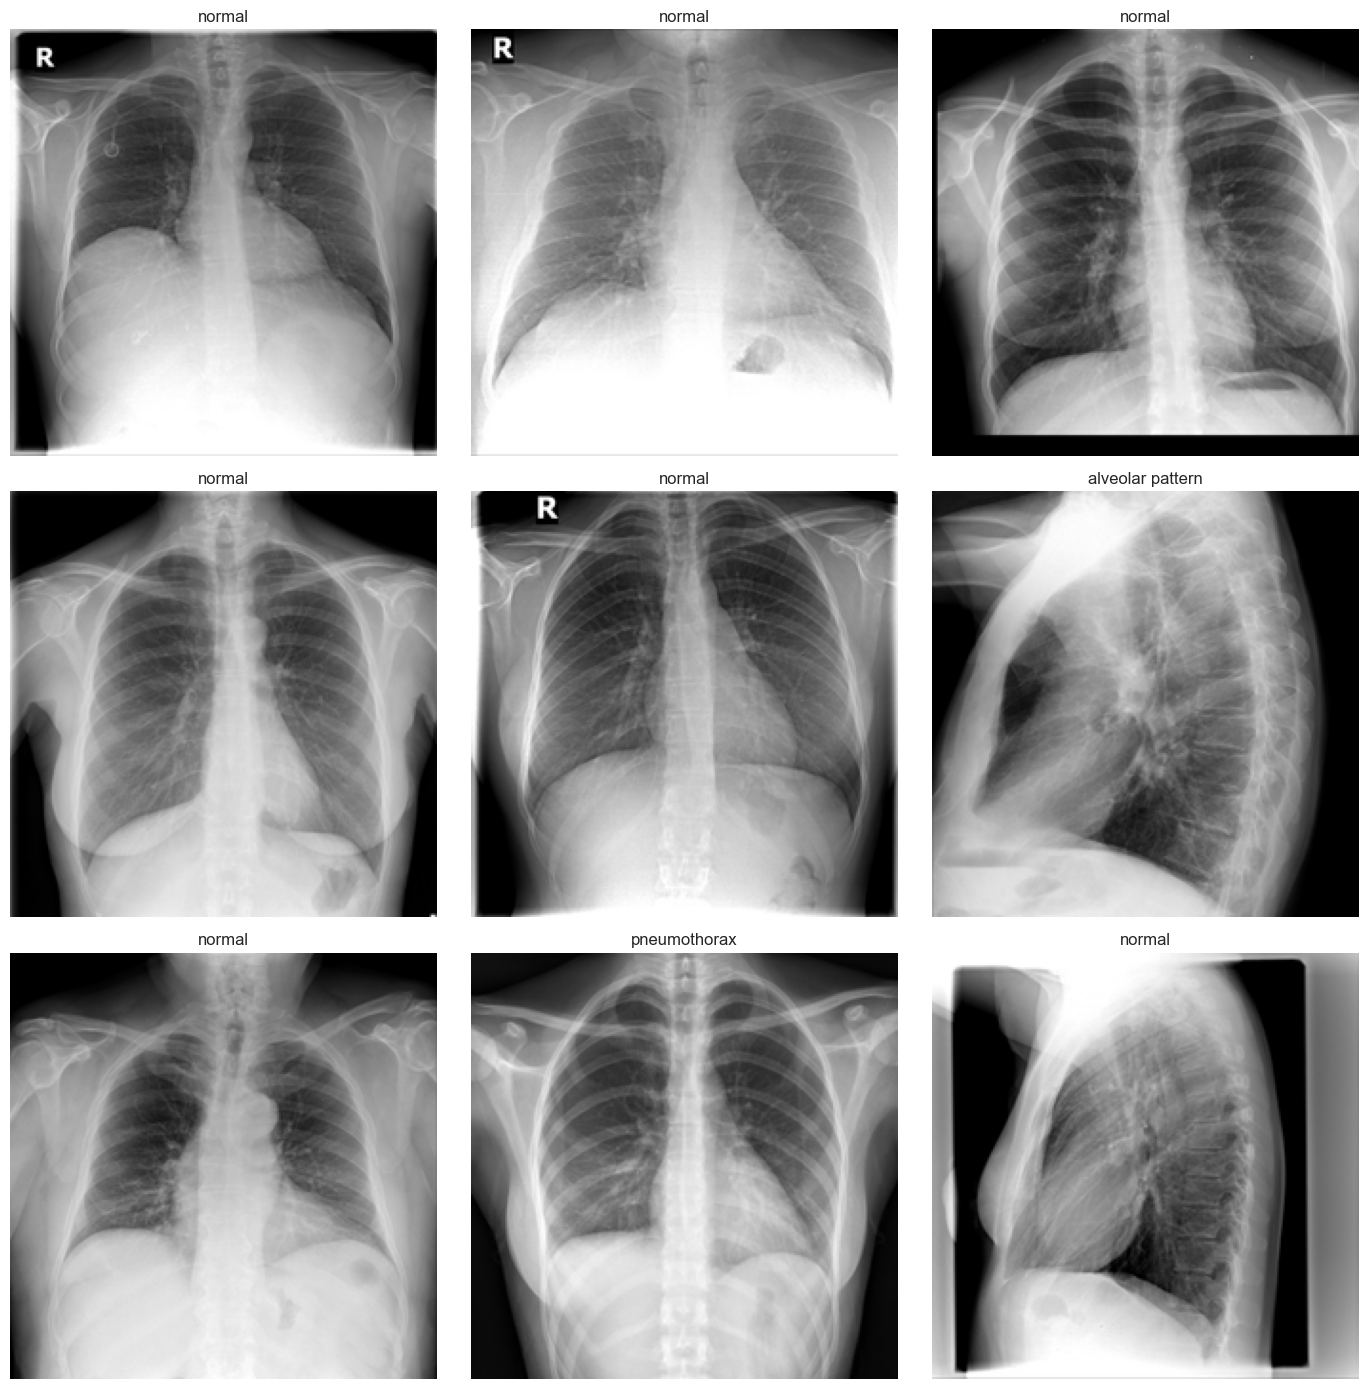

In [46]:
sample_df = filtered_df.sample(9)

fig, axes = plt.subplots(3,3, figsize=(14,14))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):

    try:

        img_path = os.path.join(
            IMAGES_PATH,
            row['ImageID']
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        ax.imshow(img, cmap='gray')

        title = ', '.join(row['FilteredLabels'])

        ax.set_title(title[:40])

        ax.axis('off')

    except:

        ax.axis('off')

plt.tight_layout()

plt.show()


In [47]:
sizes = []

sample_images = filtered_df['ImageID'].head(1000)

for img_name in tqdm(sample_images):

    try:

        path = os.path.join(IMAGES_PATH, img_name)

        img = Image.open(path)

        sizes.append(img.size)

    except:
        pass

sizes_df = pd.DataFrame(
    sizes,
    columns=['Width', 'Height']
)

display(sizes_df.describe())

100%|██████████| 1000/1000 [00:05<00:00, 170.08it/s]


,Width,Height
count,1000.0,1000.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


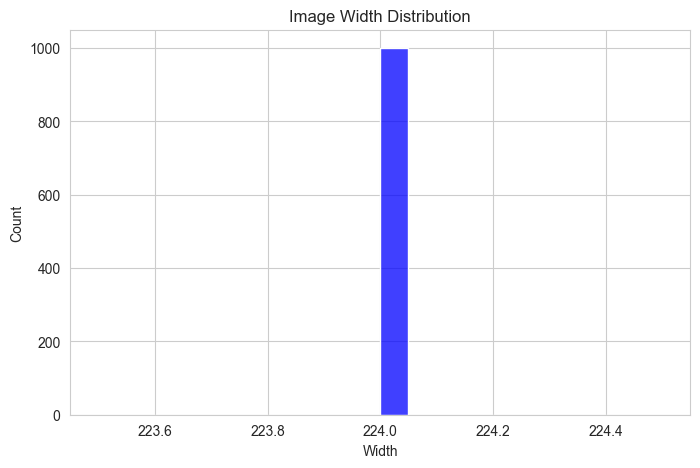

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    sizes_df['Width'],
    bins=20,
    color='blue'
)

plt.title("Image Width Distribution")

plt.show()

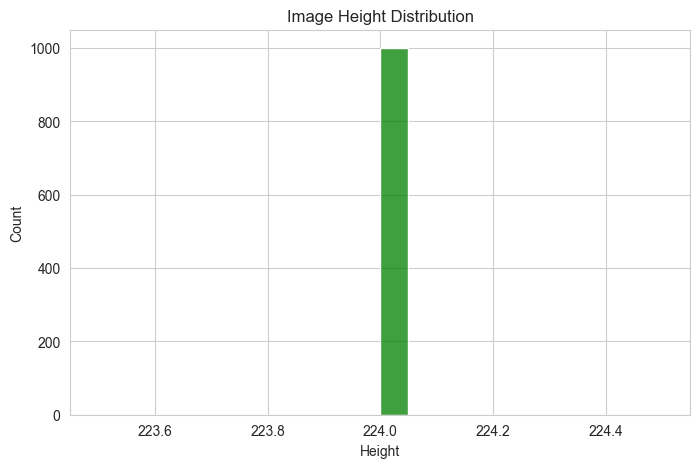

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    sizes_df['Height'],
    bins=20,
    color='green'
)

plt.title("Image Height Distribution")

plt.show()


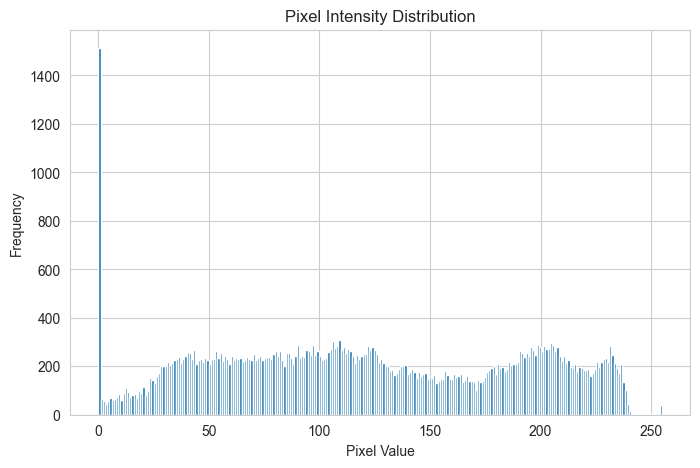

In [50]:
random_img = random.choice(
    filtered_df['ImageID'].values
)

img_path = os.path.join(
    IMAGES_PATH,
    random_img
)

img = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(8,5))

plt.hist(
    img.ravel(),
    bins=256
)

plt.title(
    "Pixel Intensity Distribution"
)

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

In [51]:
corrupted_images = []

sample_corrupted = filtered_df['ImageID'].head(5000)

for img_name in tqdm(sample_corrupted):

    try:

        path = os.path.join(
            IMAGES_PATH,
            img_name
        )

        img = cv2.imread(path)

        if img is None:

            corrupted_images.append(img_name)

    except:

        corrupted_images.append(img_name)

print("\nCorrupted Images :", len(corrupted_images))



100%|██████████| 5000/5000 [00:45<00:00, 109.78it/s] 


Corrupted Images : 0


In [52]:
co_occurrence = Counter()

for labels in filtered_df['FilteredLabels']:

    if len(labels) > 1:

        for label in labels:

            co_occurrence[label] += 1

co_df = pd.DataFrame(
    co_occurrence.items(),
    columns=['Disease', 'MultiLabelCount']
)

co_df = co_df.sort_values(
    by='MultiLabelCount',
    ascending=False
)

display(co_df)


,Disease,MultiLabelCount
5,cardiomegaly,5757
2,pleural effusion,5515
4,copd signs,5364
1,interstitial pattern,5242
0,alveolar pattern,3875
3,atelectasis,1891
6,nodule,1612
7,hilar enlargement,816
8,pulmonary fibrosis,743
9,tuberculosis sequelae,439


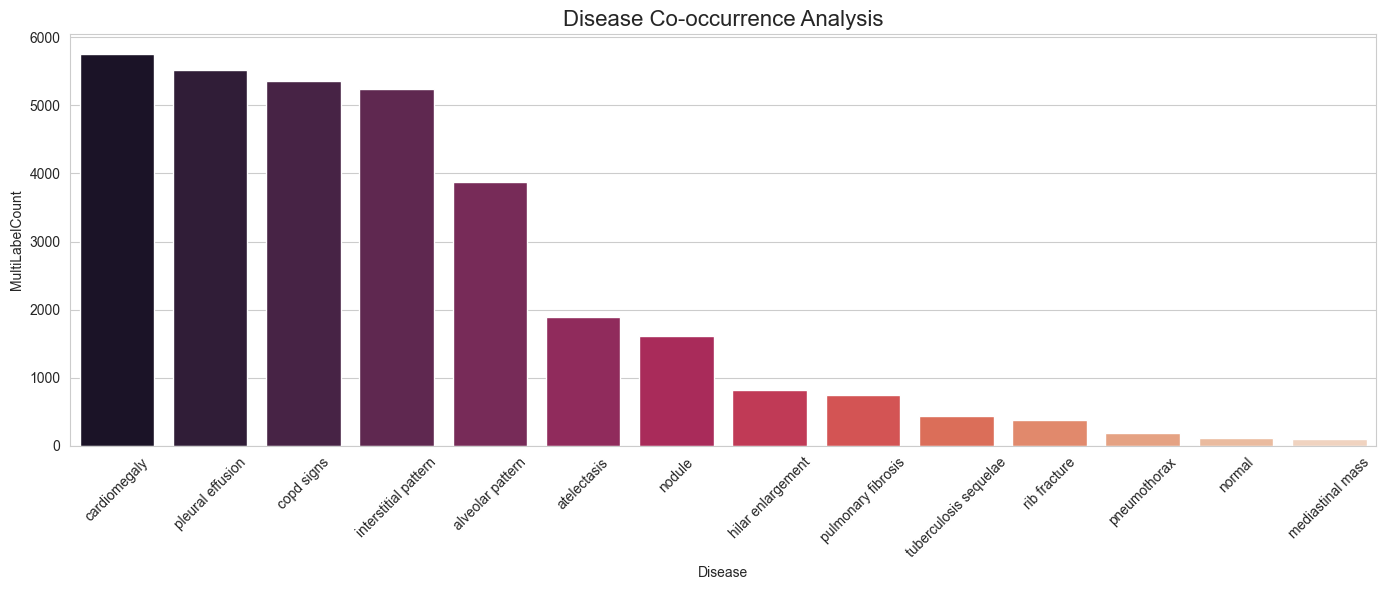

In [53]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=co_df,
    x='Disease',
    y='MultiLabelCount',
    palette='rocket'
)

plt.xticks(rotation=45)

plt.title(
    "Disease Co-occurrence Analysis",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [54]:
disease_counts['Percentage'] = (
    disease_counts['Count']
    /
    disease_counts['Count'].sum()
) * 100

display(disease_counts)

,Disease,Count,Percentage
0,normal,50616,40.567769
5,copd signs,23280,18.658481
7,cardiomegaly,15028,12.044659
4,pleural effusion,10026,8.035650
3,interstitial pattern,7831,6.276399
2,alveolar pattern,5739,4.599700
10,nodule,3781,3.030400
6,atelectasis,2905,2.328303
11,hilar enlargement,1541,1.235082
1,pulmonary fibrosis,1228,0.984219


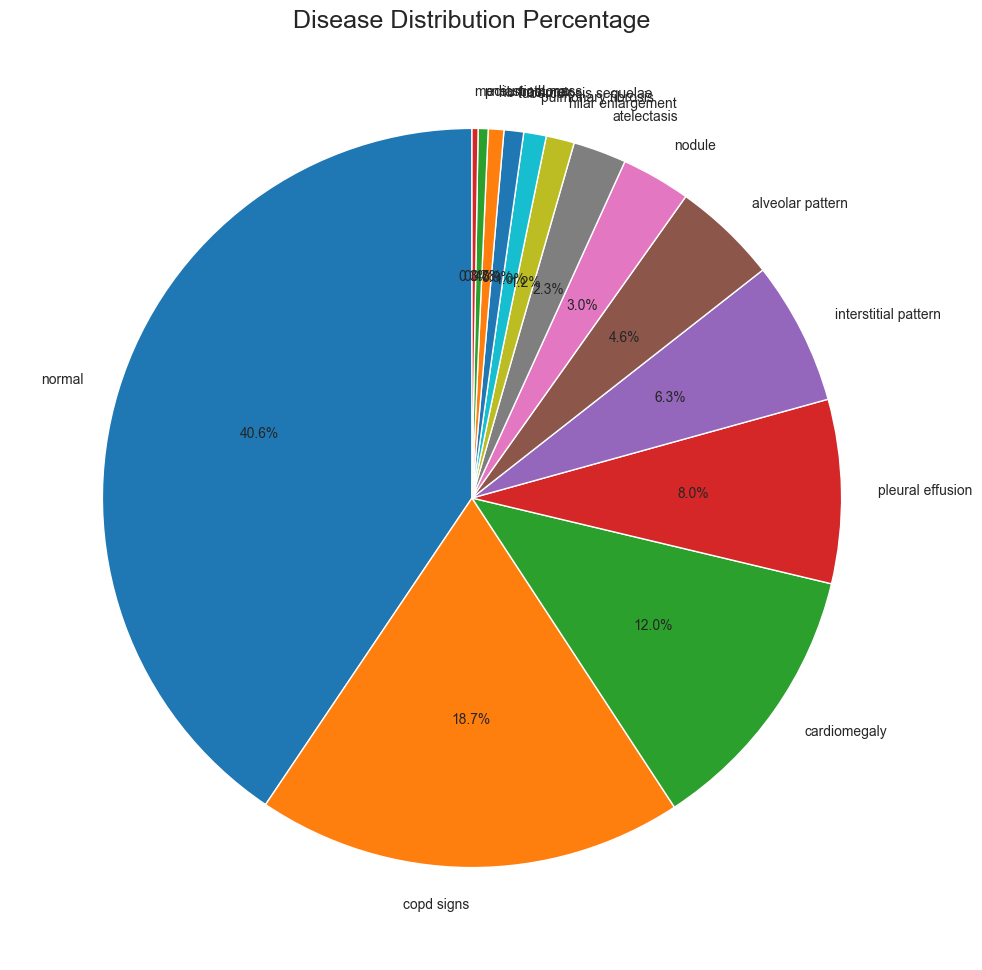

In [55]:
plt.figure(figsize=(12,12))

plt.pie(
    disease_counts['Count'],
    labels=disease_counts['Disease'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    "Disease Distribution Percentage",
    fontsize=18
)

plt.show()


In [56]:
filtered_df.to_csv(
    "filtered_padchest_14_diseases.csv",
    index=False
)

print("\nFiltered dataset saved successfully")


Filtered dataset saved successfully


In [57]:
print("\n" + "="*60)
print("FINAL EDA SUMMARY")
print("="*60)

print(f"""
Original Dataset Shape      : {df.shape}

Filtered Dataset Shape      : {filtered_df.shape}

Single Label Dataset Shape  : {single_label_df.shape}

Number of Classes           : {len(TARGET_DISEASES)}

Corrupted Images            : {len(corrupted_images)}

EDA COMPLETED SUCCESSFULLY
""")


FINAL EDA SUMMARY

Original Dataset Shape      : (160861, 36)

Filtered Dataset Shape      : (107116, 37)

Single Label Dataset Shape  : (92737, 37)

Number of Classes           : 14

Corrupted Images            : 0

EDA COMPLETED SUCCESSFULLY

